# Suicide and Depression Text Classification

Introduction

In this project, we aim to build a machine learning model that predicts whether a text expresses suicidal ideation or not. The dataset consists of user generated posts, some labeled as suicidal and others as non suicidal.

Suicide and depression are serious global health concerns, and analyzing online text can provide valuable insights for early detection and prevention. By using traditional machine learning techniques, we can identify linguistic patterns and features that differentiate between high risk and safe content.

We will perform the following steps in this notebook:
- Load and clean the dataset
- Explore and visualize the data
- Train and evaluate machine learning model

Let’s get started

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# import the necessary libraries

In [3]:
path = "../data/Suicide_Detection.csv"
Data = pd.read_csv(path)
Data.head()

# load the dataset

,Unnamed: 0,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


# Clean and Preprocess The Data 

In [4]:
Data.drop(columns='Unnamed: 0',inplace=True)

# drop unnecessary column

In [5]:
def clean_text(text):
    text = text.lower()
    cleaned = ''.join(c for c in text if c.isalpha() or c.isspace())
    return cleaned

Data['text'] = Data['text'].apply(clean_text)

# clean the data

In [6]:
Data.isnull().sum().sum()

# check for missing values

np.int64(0)

In [7]:
Data.duplicated().sum()

# check for duplicates values

np.int64(211)

In [8]:
Data.drop_duplicates(inplace=True)

In [9]:
from sklearn.preprocessing import LabelEncoder

# NOTE: The labels "suicide" and "non-suicide" are converted into numbers.
encoder = LabelEncoder()
Data['class'] = encoder.fit_transform(Data['class'])

# preprocess the data

# EDA
Exploratory Data Analysis

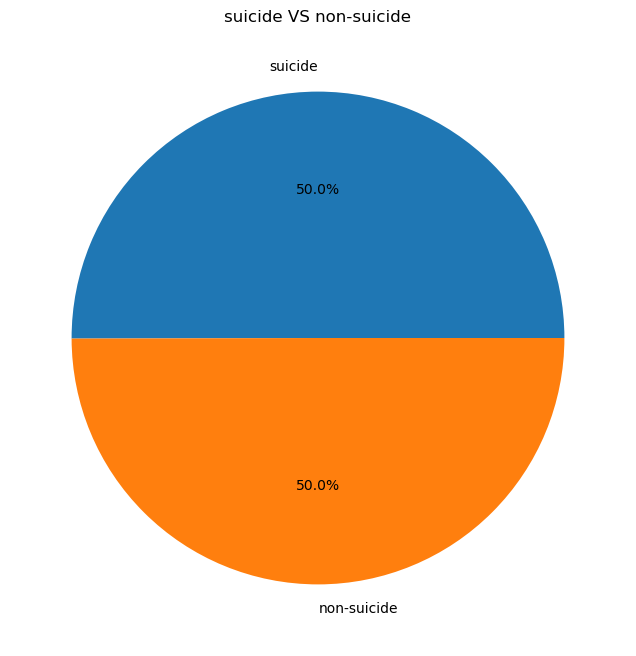

In [10]:
value = Data['class'].value_counts()

labels = ['suicide','non-suicide']

plt.figure(figsize=(8,8))
plt.pie(value,autopct='%1.1f%%',labels=labels)
plt.title('suicide VS non-suicide')
plt.show()

# explore the data with pieplot

In [11]:
x = Data['text']
y = Data['class']

from sklearn.model_selection import train_test_split

# NOTE: Splite the daata so that 70% is used to train the model, and 30% to test it. 
# NOTE: 42 ensures that the split is reproducible.
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=42)

from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(stop_words='english')
x_train_vec = vec.fit_transform(x_train)
x_test_vec = vec.transform(x_test)

# TF-IDF just measures how important each word is based on:
# 1) How often it appears in a document (Term Frequency), and
# 2) How rare it is across all documents (Inverse Document Frequency).

# There’s no deep learning, no attention mechanism ... 
# The main metric for our model is simply how frequents words are.

*So what does x_train_vec look like?*
+ 162,304 = number of training samples (rows) → That’s how many individual text examples you have in your training data.
+ 164,393 = number of unique words (columns) → That’s the size of your vocabulary after tokenization.

So the matrix conceptually looks like this:
| Sample | word₁ | word₂ | word₃ | ... | word₁₆₄₃₉₃ |
| ------ | ----- | ----- | ----- | --- | ---------- |
| text₁  | 0.1   | 0.0   | 0.0   | ... | 0.05       |
| text₂  | 0.0   | 0.2   | 0.0   | ... | 0.00       |
| ...    | ...   | ...   | ...   | ... | ...        |

Because 99% of the cells are **zeros** — most texts use only a tiny fraction of all possible words -- we store only the nonzero values and their positions. 
That’s what a sparse matrix is.

# Naive Bayes

#### Why "Bayes"
$$
P(C|W) = \frac{P(W|C) \cdot P(C)}{P(W)}
$$

We’ll need to estimate each term.
* $P(C)$: How common is suicide vs non-suicide overall (here is 50-50).
* $P(W∣C)$: probability of seeing those words if the text belongs to class C.
* $P(W)$: overall probability of seeing those words, regardless of class.

#### Why “Naive”? 
Because it assumes all words are independent given the class.
That’s not actually true in real language (words influence each other), but this simplification makes the math and computation much easier and it's surprisingly effective in practice.


In [13]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(x_train_vec,y_train)

# train the model

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [17]:
y_pred = nb.predict(x_test_vec)

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print(f"""The Accuracy : {accuracy *100:.2f}%""")

# evaluate the model with accuracy score

The Accuracy : 88.69%


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

# evaluate the model with classification report

              precision    recall  f1-score   support

           0       0.97      0.80      0.88     34775
           1       0.83      0.98      0.90     34784

    accuracy                           0.89     69559
   macro avg       0.90      0.89      0.89     69559
weighted avg       0.90      0.89      0.89     69559



In [20]:
print(f"""Train Score : {nb.score(x_train_vec,y_train) * 100:.2f}%""")
print(f"""Test Score : {nb.score(x_test_vec,y_test) * 100:.2f}%""")

# display training and test accuracy

Train Score : 90.34%
Test Score : 88.69%


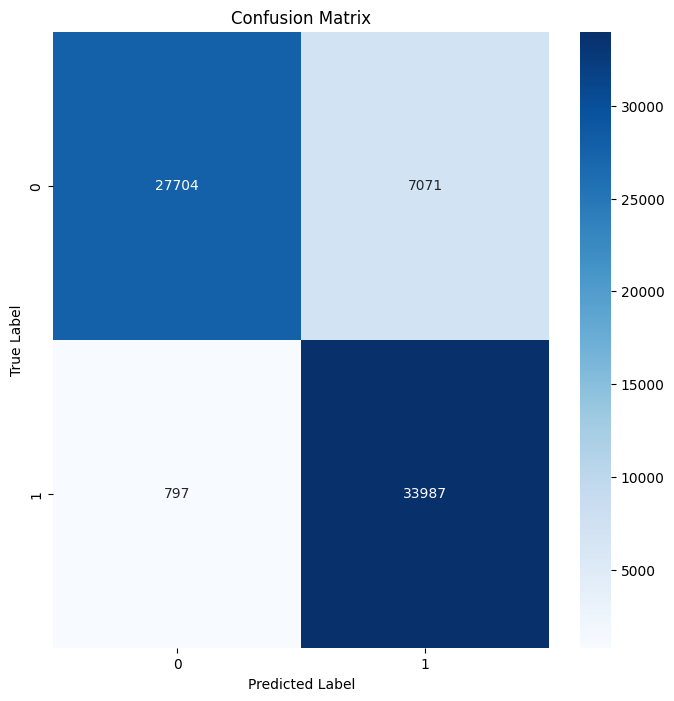

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# evaluate the model with confusion matrix

# Logistic Regression
Classic "classification model" with the signomid function and the minimization of log loss with gradient descent (The one described by 3B1B in his Videos). 

In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(x_train_vec,y_train)

# train the model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
y_pred = lr.predict(x_test_vec)

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print(f"""The Accuracy : {accuracy *100:.2f}%""")

# evaluate the model with accuracy score

The Accuracy : 93.42%


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

# evaluate the model with classification report

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     34775
           1       0.94      0.93      0.93     34784

    accuracy                           0.93     69559
   macro avg       0.93      0.93      0.93     69559
weighted avg       0.93      0.93      0.93     69559



In [24]:
print(f"""Train Score : {lr.score(x_train_vec,y_train) * 100:.2f}%""")
print(f"""Test Score : {lr.score(x_test_vec,y_test) * 100:.2f}%""")

# display training and test accuracy

Train Score : 94.18%
Test Score : 93.42%


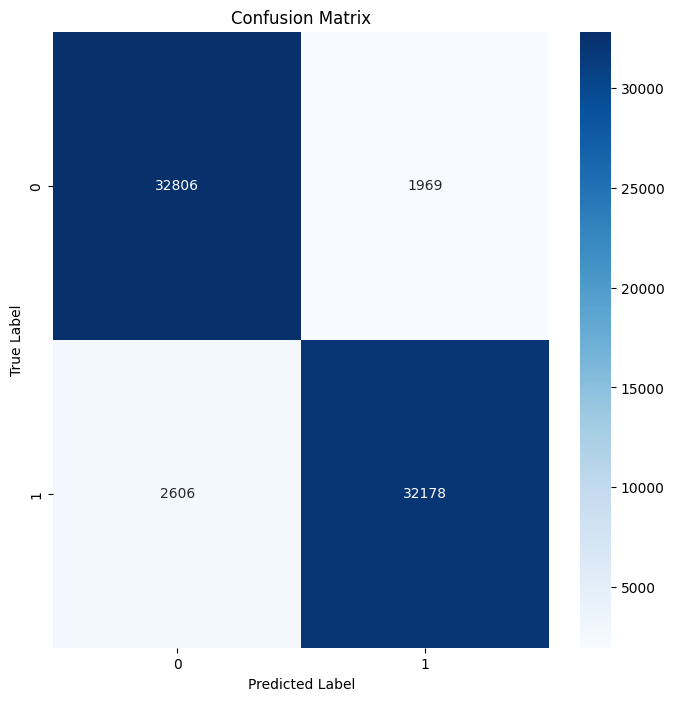

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# evaluate the model with confusion matrix

# LightGBM

This is too advanced. I haven't even installed the library. 

In [25]:
from lightgbm import LGBMClassifier

light = LGBMClassifier(n_estimators=100, learning_rate=0.1)
light.fit(x_train_vec, y_train)

ModuleNotFoundError: No module named 'lightgbm'

In [26]:
y_pred = light.predict(x_test_vec)

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print(f"""The Accuracy : {accuracy *100:.2f}%""")

# evaluate the model with accuracy score

The Accuracy : 91.33%


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

# evaluate the model with classification report

              precision    recall  f1-score   support

           0       0.90      0.93      0.91     34775
           1       0.93      0.90      0.91     34784

    accuracy                           0.91     69559
   macro avg       0.91      0.91      0.91     69559
weighted avg       0.91      0.91      0.91     69559



In [29]:
print(f"""Train Score : {light.score(x_train_vec,y_train) * 100:.2f}%""")
print(f"""Test Score : {light.score(x_test_vec,y_test) * 100:.2f}%""")

# display training and test accuracy

Train Score : 91.79%
Test Score : 91.33%


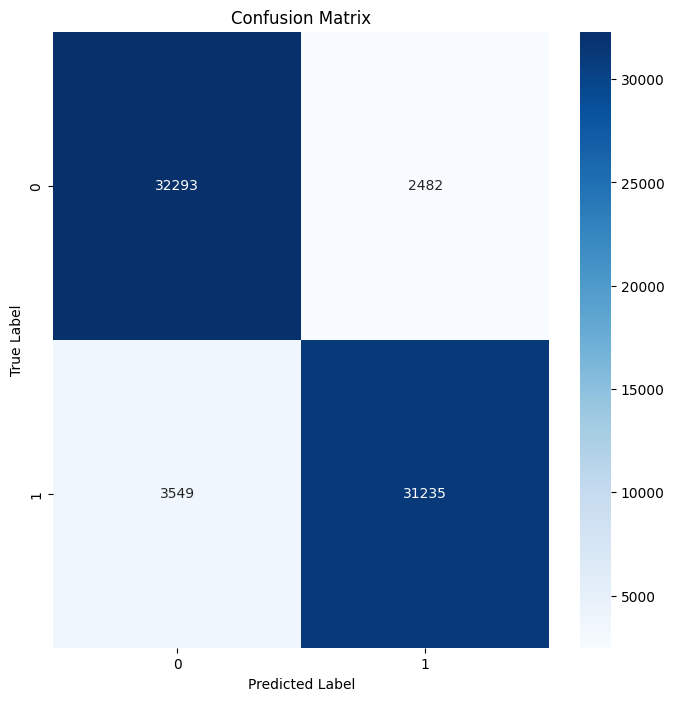

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# evaluate the model with confusion matrix